In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

# Load dataset
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

# Drop missing values to handle Sales column NaNs explicitly
df_clean = df.dropna().copy()
print(f"Cleaned dataset contains {len(df_clean)} rows.")

Cleaned dataset contains 4546 rows.


Correlation Matrix with Sales:
Sales           1.000000
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


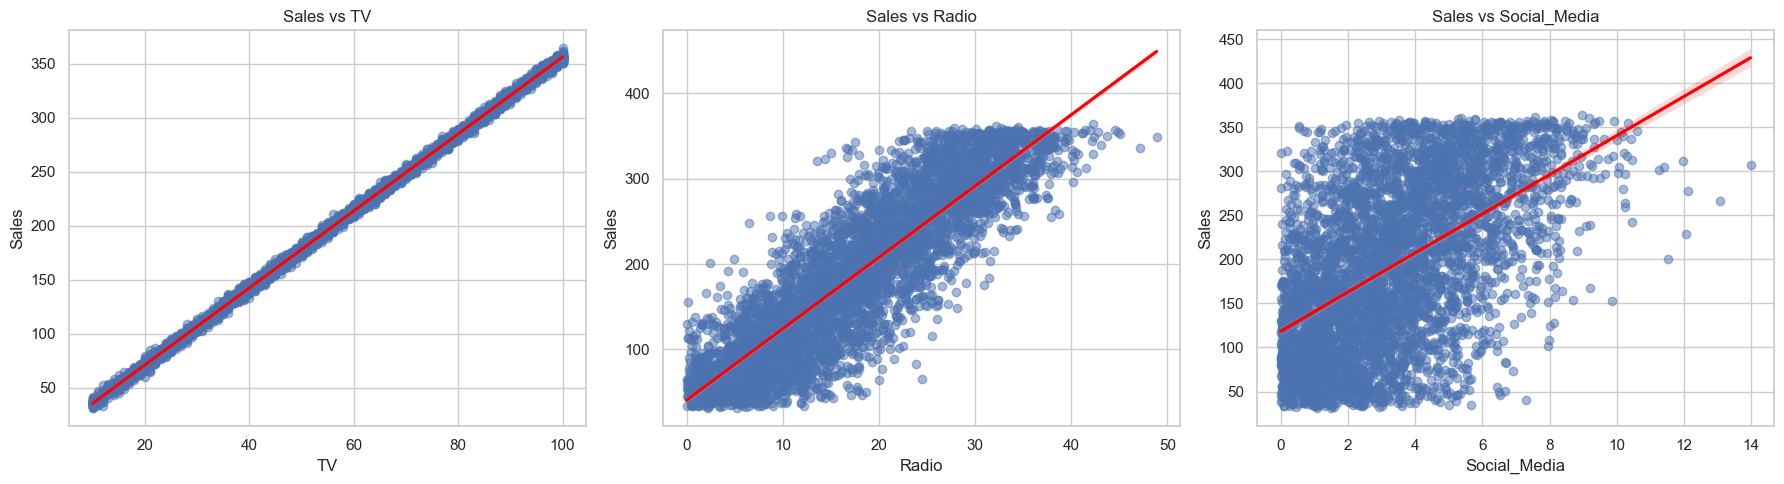

In [5]:
# Dynamically pull the exact column names from your specific file
social_col = [col for col in df_clean.columns if 'social' in col.lower()][0]
tv_col = [col for col in df_clean.columns if 'tv' in col.lower()][0]
radio_col = [col for col in df_clean.columns if 'radio' in col.lower()][0]
sales_col = [col for col in df_clean.columns if 'sales' in col.lower()][0]

# Generate and print correlation matrix
numeric_cols = [tv_col, radio_col, social_col, sales_col]
correlation_matrix = df_clean[numeric_cols].corr()
print("Correlation Matrix with Sales:")
print(correlation_matrix[sales_col].sort_values(ascending=False))

# Plot the relationship scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.regplot(data=df_clean, x=tv_col, y=sales_col, ax=axes[0], scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
axes[0].set_title(f"Sales vs {tv_col}")
sns.regplot(data=df_clean, x=radio_col, y=sales_col, ax=axes[1], scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
axes[1].set_title(f"Sales vs {radio_col}")
sns.regplot(data=df_clean, x=social_col, y=sales_col, ax=axes[2], scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
axes[2].set_title(f"Sales vs {social_col}")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:14:34   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

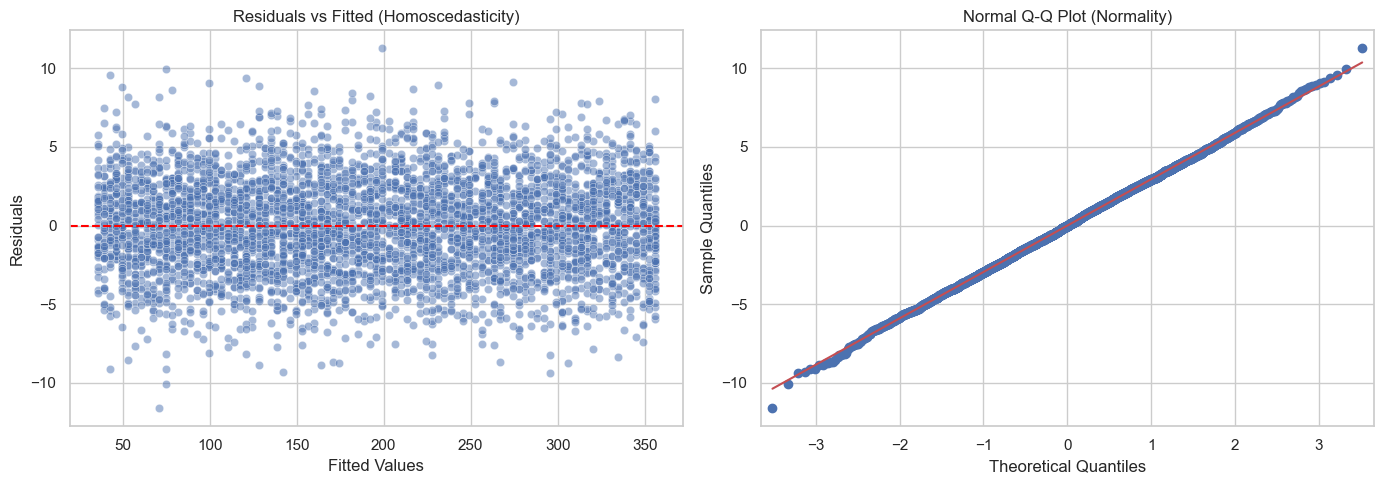

In [6]:
# Build OLS Regression with TV (strongest correlated channel)
X = df_clean['TV']
y = df_clean['Sales']
X_with_constant = sm.add_constant(X)

model = sm.OLS(y, X_with_constant).fit()
print(model.summary())

# Assumption Checking Plots
residuals = model.resid
fitted_values = model.fittedvalues
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Homoscedasticity scatter plot
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0], alpha=0.5)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Homoscedasticity)')

# Normality Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot (Normality)')
plt.tight_layout()
plt.show()